In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from labellines import labelLine, labelLines
from libra_toolbox.tritium.model import (
    quantity_to_activity,
    activity_to_quantity,
)
from libra_toolbox.tritium.plotting import (
    ureg,
    plot_bars,
    plot_integrated_top_release,
    plot_integrated_wall_release,
    plot_irradiation,
    plot_sample_activity_top,
    plot_sample_activity_wall,
    plot_salt_inventory,
    plot_top_release,
    plot_wall_release,
)

ureg.mpl_formatter = "{:~P}"
# remove top and right axes by default
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
# set axis below true by default
plt.rcParams["axes.axisbelow"] = True

from tritium_model_errors import *

# Create outputs directory
os.makedirs('outputs', exist_ok=True)


/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-0-3 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-0-4 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-1-4 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-2-3 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-2-4 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarn

40.80700268729372 becquerel 15.577710896139696 becquerel
0.42219947016795706 0.2963284017797677
Processed data file not found, creating it in ../../data/processed_data.json
Processed data stored in ../../data/processed_data.json


Quantity of T consumed: 1.62×10¹³ particle
Uncertainty on T consumed: 1.79×10¹¹ particle
Quantity of T consumed: 2.90×10⁴ Bq
Quantity of T produced IV: 4.08×10¹ Bq
Quantity of T produced: 2.28×10¹⁰ particle
Measured TBR: 1.95e-03 particle / neutron
1.658520126599997 dimensionless


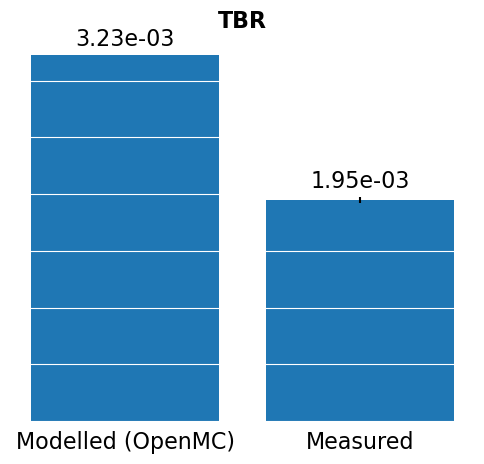

In [2]:
print(f"Quantity of T consumed: {T_consumed.to(ureg.particle):.2e~P}")
print(
    f"Uncertainty on T consumed: {(neutron_rate_relative_uncertainty * T_consumed).to(ureg.particle):.2e~P}"
)
print(f"Quantity of T consumed: {quantity_to_activity(T_consumed).to(ureg.Bq):.2e~P}")
print(f"Quantity of T produced IV: {T_produced_IV:.2e~P}")
print(
    f"Quantity of T produced: {activity_to_quantity(T_produced_IV).to(ureg.particle):.2e~P}"
)
print(f"Measured TBR: {measured_TBR:.2e}")
plt.figure(figsize=(6, 5))
bars = plt.bar(
    [0, 1],
    [calculated_TBR, measured_TBR],
    tick_label=["Modelled (OpenMC)", "Measured"],
    yerr=[0, measured_TBR_error],
)

plt.bar_label(bars, fontsize=16, fmt="%.2e", padding=3)
plt.title("TBR", weight="bold", fontsize=16)
plt.ylabel("")
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().set_yticklabels([])
plt.gca().set_xticklabels
plt.gca().tick_params(axis="both", which="both", left=False, bottom=False, labelsize=16)
plt.gca().set_axisbelow(False)
plt.grid(axis="y", alpha=1, color="white", zorder=-10)
# plt.tight_layout()
print((calculated_TBR / measured_TBR).to(ureg.dimensionless))
plt.savefig("outputs/tbr_comparison.pdf", bbox_inches="tight")
plt.show()


In [3]:
baby_model.run(100 * ureg.day)

/root/miniconda3/envs/flibe-1l-run-2/lib/python3.13/site-packages/scipy/integrate/_ivp/base.py:24: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(fun(t, y), dtype=dtype)


In [4]:
print(f"Transport:")
print(f"  mass transport coeff top: {baby_model.k_top:.2e~P}")
print(f"  mass transport coeff wall: {baby_model.k_wall:.2e~P}")

print("Source:")
print(f"  TBR: {baby_model.TBR:.2e~P}")
print(f"  neutron rate: {baby_model.neutron_rate:.2e~P}")
print(f"  neutron rate * TBR: {baby_model.neutron_rate * baby_model.TBR:.2e~P}")
# print(f"  k_top/k_wall: {baby_model.k_top/baby_model.k_wall:.2f~P}")

print("Geometry:")
print(f"  volume: {baby_model.volume.to(ureg.cm**3):.2f~P}")
print(f"  top area: {baby_model.A_top.to(ureg.cm**2):.2f~P}")
print(f"  wall area: {baby_model.A_wall.to(ureg.cm**2):.2f~P}")

Transport:
  mass transport coeff top: 3.87×10⁻⁶ m/s
  mass transport coeff wall: 0.00×10⁰ m/s
Source:
  TBR: 1.95×10⁻³ particle/n
  neutron rate: 1.80×10⁹ n/s
  neutron rate * TBR: 3.50×10⁶ particle/s
Geometry:
  volume: 1000.00 cm³
  top area: 153.94 cm²
  wall area: 445.87 cm²


Temperature channels loaded:
  DIP TC: 53470 data points
  SIDE TC: 53470 data points
  OV SIDE: 53470 data points
  FURNACE: 53470 data points
  Dip heater: 7 setpoints


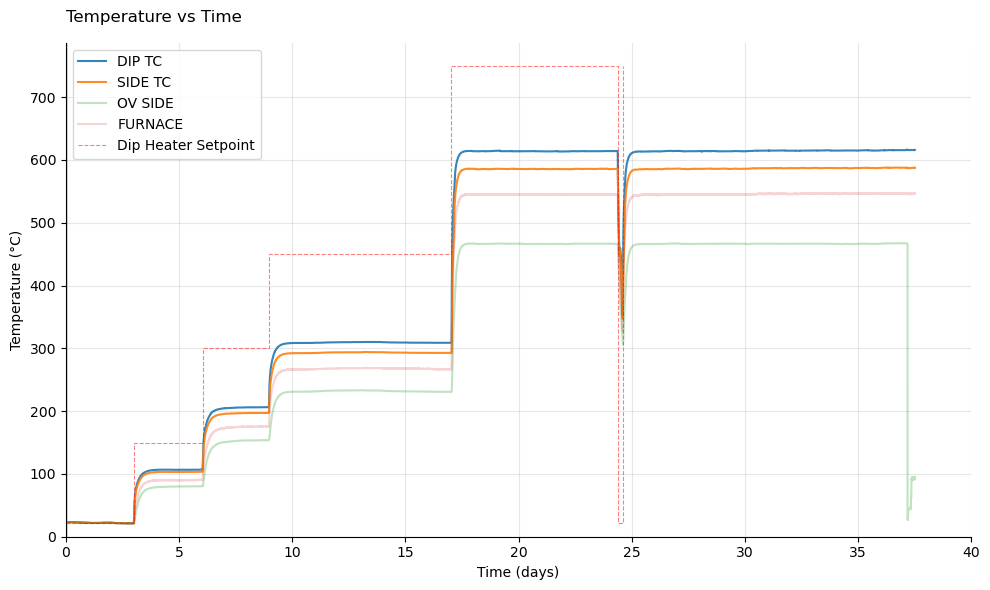

In [5]:
# Load temperature data
import sys
sys.path.append('../temperature')
from temperature_data import load_temperature_data

temp_data = load_temperature_data()

# Access temperature channels
dip_tc = temp_data['TC1']      # DIP TC
side_tc = temp_data['TC2']     # SIDE TC
ov_side_tc = temp_data['TC3']  # OV SIDE
furnace_tc = temp_data['TC4']  # FURNACE
dip_heater = temp_data['dip_heater']

print(f"Temperature channels loaded:")
print(f"  {dip_tc.tc_label}: {len(dip_tc.get_temperature())} data points")
print(f"  {side_tc.tc_label}: {len(side_tc.get_temperature())} data points")
print(f"  {ov_side_tc.tc_label}: {len(ov_side_tc.get_temperature())} data points")
print(f"  {furnace_tc.tc_label}: {len(furnace_tc.get_temperature())} data points")
print(f"  Dip heater: {len(dip_heater.get_setpoint_times())} setpoints")

# Plot temperature vs time
plt.figure(figsize=(10, 6))

# Plot thermocouple data
plt.plot(dip_tc.get_times_days(), dip_tc.get_temperature(), 
         label=dip_tc.tc_label, linewidth=1.5, alpha=0.9)
plt.plot(side_tc.get_times_days(), side_tc.get_temperature(), 
         label=side_tc.tc_label, linewidth=1.5, alpha=0.9)
plt.plot(ov_side_tc.get_times_days(), ov_side_tc.get_temperature(), 
         label=ov_side_tc.tc_label, linewidth=1.5, alpha=0.3)
plt.plot(furnace_tc.get_times_days(), furnace_tc.get_temperature(), 
         label=furnace_tc.tc_label, linewidth=1.5, alpha=0.2)

# Plot dip heater setpoints as step function
setpoint_times = dip_heater.get_setpoint_times()
setpoint_values = dip_heater.get_setpoint_values()
plt.step(setpoint_times, setpoint_values, where='post',
         label='Dip Heater Setpoint', linewidth=0.8, linestyle='--', color='red', alpha=0.5)

# Add irradiation shading
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=0.3)

plt.xlabel('Time (days)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Time', loc='left', pad=15)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.xlim(left=0, right=40)
plt.ylim(bottom=0)

plt.tight_layout()
plt.savefig('outputs/temperature_vs_time.pdf', bbox_inches='tight')
plt.show()

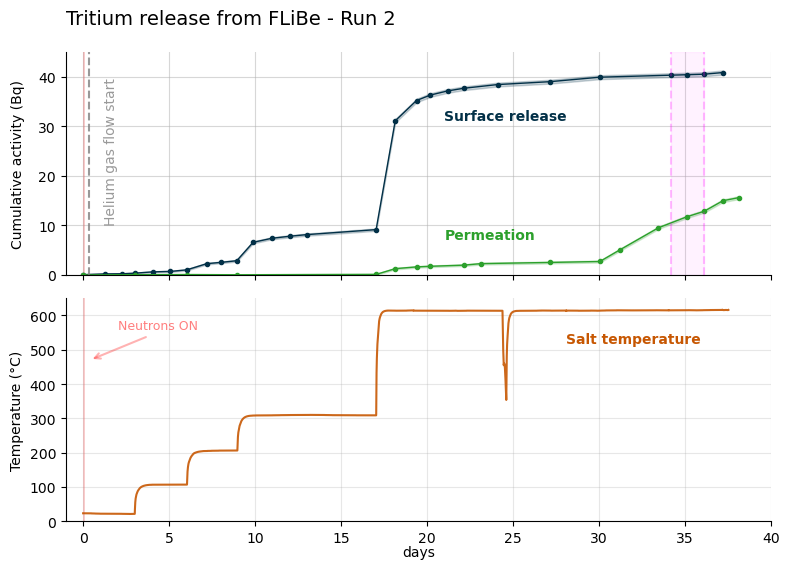

In [6]:
# ============================================================================
# DATA LOADING AND BASIC PLOTTING
# ============================================================================
from datetime import datetime
import json

# Create figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.8), sharex=True)

# Get cumulative activities and their errors
iv_cumulative = IV_stream_with_errors.get_cumulative_activity("total")
iv_errors = IV_stream_with_errors.get_cumulative_activity_errors("total")

ov_cumulative = OV_stream_with_errors.get_cumulative_activity("total")
ov_errors = OV_stream_with_errors.get_cumulative_activity_errors("total")

# Convert times to numpy arrays for plotting
times_top = np.array([t.magnitude for t in replacement_times_top])
times_walls = np.array([t.magnitude for t in replacement_times_walls])

# Extract magnitudes for cumulative values (they have units)
iv_cumulative_mag = iv_cumulative.magnitude if hasattr(iv_cumulative, 'magnitude') else iv_cumulative
ov_cumulative_mag = ov_cumulative.magnitude if hasattr(ov_cumulative, 'magnitude') else ov_cumulative

# Load timing data from general.json
with open("../../data/general.json", "r") as f:
    general_data_plot = json.load(f)

run_start = datetime.strptime(
    general_data_plot["timestamps"]["run_start"], "%m/%d/%Y %H:%M"
)
flow_change_item = next(
    (
        item
        for item in general_data_plot["cover_gas"]["flow_rate_sample"]
        if item["value"] != 0
    ),
    None,
)

if flow_change_item is not None:
    flow_change = datetime.strptime(flow_change_item["set_time"], "%m/%d/%Y %H:%M")
    flow_change_days = (flow_change - run_start).total_seconds() / 86400.0
else:
    flow_change_days = None

# Extract H2 switch times
if len(cover_gas_switch_deltatimes) >= 2:
    h2_start_days = cover_gas_switch_deltatimes[0].magnitude
    h2_end_days = cover_gas_switch_deltatimes[1].magnitude
else:
    h2_start_days = None
    h2_end_days = None

# Get temperature data for bottom plot
temp_times = dip_tc.get_times_days()
temp_values = dip_tc.get_temperature()

# ============================================================================
# TUNABLE PLOT PARAMETERS - Adjust these values for fine-tuning
# ============================================================================
params = {
    # ---- Figure dimensions ----
    'figsize': (8, 5.8),
    
    # ---- Top plot: Tritium release ----
    'grid_alpha': 0.5,
    'line_width': 1,
    'marker_size': 3,
    'fill_alpha': 0.2,
    'irradiation_alpha': 0.3,
    
    # Top plot - IV (inner vessel) line
    'iv_color': "#023047",
    'iv_label_x': 21,
    'iv_label_y': 32,
    'iv_label_text': 'Surface release',
    'iv_label_fontsize': 10,
    
    # Top plot - OV (outer vessel) line
    'ov_color': "tab:green",
    'ov_label_x': 21,
    'ov_label_y': 8,
    'ov_label_text': 'Permeation',
    'ov_label_fontsize': 10,
    
    # Top plot - Flow change marker
    'flow_change_color': 'gray',
    'flow_change_linestyle': '--',
    'flow_change_linewidth': 1.5,
    'flow_change_alpha': 0.8,
    'flow_change_label_x_offset': 0.9,
    'flow_change_label_y': 25,
    'flow_change_label_text': 'Helium gas flow start',
    'flow_change_label_fontsize': 10,
    
    # Top plot - H2 period shading
    'h2_color': 'magenta',
    'h2_line_alpha': 0.25,
    'h2_span_alpha': 0.05,
    
    # Top plot - Axes labels and limits
    'ax1_ylabel': "Cumulative activity (Bq)",
    'ax1_ylabel_pad': 10,
    'ax1_title': "Tritium release from FLiBe - Run 2",
    'ax1_title_pad': 20,
    'ax1_title_fontsize': 14,
    'ax1_ylim_min': 0,
    'ax1_ylim_max': 45,
    'ax1_xlim_min': -1,
    'ax1_xlim_max': 40,
    
    # ---- Bottom plot: Temperature ----
    'temp_color': "#C75702",
    'temp_linewidth': 1.5,
    'temp_alpha': 0.9,
    'temp_label_x': 32,
    'temp_label_y': 510,
    'temp_label_text': 'Salt temperature',
    'temp_label_fontsize': 10,
    
    # Bottom plot - "Neutrons ON" annotation
    'neutrons_text_x': 2,
    'neutrons_text_y': 560,
    'neutrons_text': 'Neutrons ON',
    'neutrons_text_color': 'red',
    'neutrons_text_alpha': 0.5,
    'neutrons_text_fontsize': 9,
    
    # Bottom plot - Arrow annotation
    'arrow_xy': (0.4, 470),
    'arrow_xytext': (3.8, 540),
    'arrow_color': 'red',
    'arrow_alpha': 0.3,
    'arrow_lw': 1.5,
    
    # Bottom plot - Axes labels and limits
    'ax2_xlabel': 'days',
    'ax2_xlabel_pad': 0,
    'ax2_ylabel': 'Temperature (°C)',
    'ax2_grid_alpha': 0.3,
    'ax2_ylim_min': 0,
    'ax2_ylim_max': 650,
}

# ============================================================================
# PLOTTING AND STYLING USING PARAMETERS
# ============================================================================

# Top plot: Tritium release
plt.sca(ax1)
ax1.grid(alpha=params['grid_alpha'])

# Plot data lines with error bands
ax1.plot(times_top, iv_cumulative_mag, color=params['iv_color'], linewidth=params['line_width'], marker='o', markersize=params['marker_size'])
ax1.fill_between(times_top, iv_cumulative_mag - iv_errors, iv_cumulative_mag + iv_errors, color=params['iv_color'], alpha=params['fill_alpha'])

ax1.plot(times_walls, ov_cumulative_mag, color=params['ov_color'], linewidth=params['line_width'], marker='o', markersize=params['marker_size'])
ax1.fill_between(times_walls, ov_cumulative_mag - ov_errors, ov_cumulative_mag + ov_errors, color=params['ov_color'], alpha=params['fill_alpha'])

# Flow change marker
if flow_change_days is not None:
    ax1.axvline(x=flow_change_days, color=params['flow_change_color'], linestyle=params['flow_change_linestyle'], 
                linewidth=params['flow_change_linewidth'], alpha=params['flow_change_alpha'])
    ax1.text(flow_change_days + params['flow_change_label_x_offset'], params['flow_change_label_y'], 
             params['flow_change_label_text'], color=params['flow_change_color'], alpha=params['flow_change_alpha'], 
             rotation=90, va='center', fontsize=params['flow_change_label_fontsize'])

# H2 cover gas period shading
if h2_start_days is not None and h2_end_days is not None:
    ax1.axvline(x=h2_start_days, color=params['h2_color'], linestyle='--', linewidth=params['flow_change_linewidth'], alpha=params['h2_line_alpha'])
    ax1.axvline(x=h2_end_days, color=params['h2_color'], linestyle='--', linewidth=params['flow_change_linewidth'], alpha=params['h2_line_alpha'])
    ax1.axvspan(h2_start_days, h2_end_days, color=params['h2_color'], alpha=params['h2_span_alpha'])

# Add data labels
ax1.text(params['iv_label_x'], params['iv_label_y'], params['iv_label_text'], 
         color=params['iv_color'], va='center', fontsize=params['iv_label_fontsize'], fontweight='bold')
ax1.text(params['ov_label_x'], params['ov_label_y'], params['ov_label_text'], 
         color=params['ov_color'], va='center', fontsize=params['ov_label_fontsize'], fontweight='bold')

# Add irradiation shading
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=params['irradiation_alpha'])

# Set labels, title, and limits
ax1.set_ylabel(params['ax1_ylabel'], labelpad=params['ax1_ylabel_pad'])
ax1.set_title(params['ax1_title'], loc="left", pad=params['ax1_title_pad'], fontsize=params['ax1_title_fontsize'])
ax1.set_ylim(params['ax1_ylim_min'], params['ax1_ylim_max'])
ax1.set_xlim(params['ax1_xlim_min'], params['ax1_xlim_max'])

# Bottom plot: Temperature profile
plt.sca(ax2)
ax2.plot(temp_times, temp_values, linewidth=params['temp_linewidth'], alpha=params['temp_alpha'], color=params['temp_color'])

# Add temperature label
ax2.text(params['temp_label_x'], params['temp_label_y'], params['temp_label_text'], 
         color=params['temp_color'], va='bottom', ha='center', fontsize=params['temp_label_fontsize'], fontweight='bold')

# Add "Neutrons ON" annotation with arrow
ax2.text(params['neutrons_text_x'], params['neutrons_text_y'], params['neutrons_text'], 
         color=params['neutrons_text_color'], alpha=params['neutrons_text_alpha'], fontsize=params['neutrons_text_fontsize'])
ax2.annotate('', xy=params['arrow_xy'], xytext=params['arrow_xytext'],
             arrowprops=dict(arrowstyle='->', color=params['arrow_color'], alpha=params['arrow_alpha'], lw=params['arrow_lw']))

# Add irradiation shading
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=params['irradiation_alpha'])

# Set labels, grid, and limits
ax2.set_xlabel(params['ax2_xlabel'], labelpad=params['ax2_xlabel_pad'])
ax2.set_ylabel(params['ax2_ylabel'])
ax2.grid(alpha=params['ax2_grid_alpha'])
ax2.set_xlim(params['ax1_xlim_min'], params['ax1_xlim_max'])
ax2.set_ylim(params['ax2_ylim_min'], params['ax2_ylim_max'])

# Save and display figure
plt.tight_layout()
plt.savefig('outputs/tritium_and_temperature.pdf', bbox_inches='tight')
plt.savefig('outputs/tritium_and_temperature.svg', bbox_inches='tight')
plt.savefig('outputs/tritium_and_temperature.png', bbox_inches='tight')
plt.show()

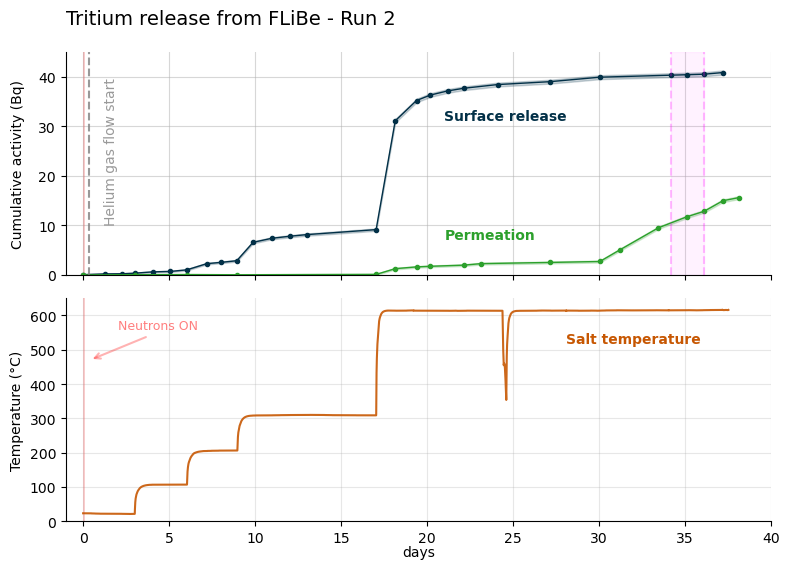

In [7]:
# ============================================================================
# DATA LOADING AND BASIC PLOTTING
# ============================================================================
from datetime import datetime
import json

# Create figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.8), sharex=True)

# Get cumulative activities and their errors
iv_cumulative = IV_stream_with_errors.get_cumulative_activity("total")
iv_errors = IV_stream_with_errors.get_cumulative_activity_errors("total")

ov_cumulative = OV_stream_with_errors.get_cumulative_activity("total")
ov_errors = OV_stream_with_errors.get_cumulative_activity_errors("total")

# Convert times to numpy arrays for plotting
times_top = np.array([t.magnitude for t in replacement_times_top])
times_walls = np.array([t.magnitude for t in replacement_times_walls])

# Extract magnitudes for cumulative values (they have units)
iv_cumulative_mag = iv_cumulative.magnitude if hasattr(iv_cumulative, 'magnitude') else iv_cumulative
ov_cumulative_mag = ov_cumulative.magnitude if hasattr(ov_cumulative, 'magnitude') else ov_cumulative

# Load timing data from general.json
with open("../../data/general.json", "r") as f:
    general_data_plot = json.load(f)

run_start = datetime.strptime(
    general_data_plot["timestamps"]["run_start"], "%m/%d/%Y %H:%M"
)
flow_change_item = next(
    (
        item
        for item in general_data_plot["cover_gas"]["flow_rate_sample"]
        if item["value"] != 0
    ),
    None,
)

if flow_change_item is not None:
    flow_change = datetime.strptime(flow_change_item["set_time"], "%m/%d/%Y %H:%M")
    flow_change_days = (flow_change - run_start).total_seconds() / 86400.0
else:
    flow_change_days = None

# Extract H2 switch times
if len(cover_gas_switch_deltatimes) >= 2:
    h2_start_days = cover_gas_switch_deltatimes[0].magnitude
    h2_end_days = cover_gas_switch_deltatimes[1].magnitude
else:
    h2_start_days = None
    h2_end_days = None

# Get temperature data for bottom plot
temp_times = dip_tc.get_times_days()
temp_values = dip_tc.get_temperature()

# ============================================================================
# TUNABLE PLOT PARAMETERS - Adjust these values for fine-tuning
# ============================================================================
params = {
    # ---- Figure dimensions ----
    'figsize': (8, 5.8),
    
    # ---- Top plot: Tritium release ----
    'grid_alpha': 0.5,
    'line_width': 1,
    'marker_size': 3,
    'fill_alpha': 0.2,
    'irradiation_alpha': 0.3,
    
    # Top plot - IV (inner vessel) line
    'iv_color': "#023047",
    'iv_label_x': 21,
    'iv_label_y': 32,
    'iv_label_text': 'Surface release',
    'iv_label_fontsize': 10,
    
    # Top plot - OV (outer vessel) line
    'ov_color': "tab:green",
    'ov_label_x': 21,
    'ov_label_y': 8,
    'ov_label_text': 'Permeation',
    'ov_label_fontsize': 10,
    
    # Top plot - Flow change marker
    'flow_change_color': 'gray',
    'flow_change_linestyle': '--',
    'flow_change_linewidth': 1.5,
    'flow_change_alpha': 0.8,
    'flow_change_label_x_offset': 0.9,
    'flow_change_label_y': 25,
    'flow_change_label_text': 'Helium gas flow start',
    'flow_change_label_fontsize': 10,
    
    # Top plot - H2 period shading
    'h2_color': 'magenta',
    'h2_line_alpha': 0.25,
    'h2_span_alpha': 0.05,
    
    # Top plot - Axes labels and limits
    'ax1_ylabel': "Cumulative activity (Bq)",
    'ax1_ylabel_pad': 10,
    'ax1_title': "Tritium release from FLiBe - Run 2",
    'ax1_title_pad': 20,
    'ax1_title_fontsize': 14,
    'ax1_ylim_min': 0,
    'ax1_ylim_max': 45,
    'ax1_xlim_min': -1,
    'ax1_xlim_max': 40,
    
    # ---- Bottom plot: Temperature ----
    'temp_color': "#C75702",
    'temp_linewidth': 1.5,
    'temp_alpha': 0.9,
    'temp_label_x': 32,
    'temp_label_y': 510,
    'temp_label_text': 'Salt temperature',
    'temp_label_fontsize': 10,
    
    # Bottom plot - "Neutrons ON" annotation
    'neutrons_text_x': 2,
    'neutrons_text_y': 560,
    'neutrons_text': 'Neutrons ON',
    'neutrons_text_color': 'red',
    'neutrons_text_alpha': 0.5,
    'neutrons_text_fontsize': 9,
    
    # Bottom plot - Arrow annotation
    'arrow_xy': (0.4, 470),
    'arrow_xytext': (3.8, 540),
    'arrow_color': 'red',
    'arrow_alpha': 0.3,
    'arrow_lw': 1.5,
    
    # Bottom plot - Axes labels and limits
    'ax2_xlabel': 'days',
    'ax2_xlabel_pad': 0,
    'ax2_ylabel': 'Temperature (°C)',
    'ax2_grid_alpha': 0.3,
    'ax2_ylim_min': 0,
    'ax2_ylim_max': 650,
}

# ============================================================================
# PLOTTING AND STYLING USING PARAMETERS
# ============================================================================

# Top plot: Tritium release
plt.sca(ax1)
ax1.grid(alpha=params['grid_alpha'])

# Plot data lines with error bands
ax1.plot(times_top, iv_cumulative_mag, color=params['iv_color'], linewidth=params['line_width'], marker='o', markersize=params['marker_size'])
ax1.fill_between(times_top, iv_cumulative_mag - iv_errors, iv_cumulative_mag + iv_errors, color=params['iv_color'], alpha=params['fill_alpha'])

ax1.plot(times_walls, ov_cumulative_mag, color=params['ov_color'], linewidth=params['line_width'], marker='o', markersize=params['marker_size'])
ax1.fill_between(times_walls, ov_cumulative_mag - ov_errors, ov_cumulative_mag + ov_errors, color=params['ov_color'], alpha=params['fill_alpha'])

# Flow change marker
if flow_change_days is not None:
    ax1.axvline(x=flow_change_days, color=params['flow_change_color'], linestyle=params['flow_change_linestyle'], 
                linewidth=params['flow_change_linewidth'], alpha=params['flow_change_alpha'])
    ax1.text(flow_change_days + params['flow_change_label_x_offset'], params['flow_change_label_y'], 
             params['flow_change_label_text'], color=params['flow_change_color'], alpha=params['flow_change_alpha'], 
             rotation=90, va='center', fontsize=params['flow_change_label_fontsize'])

# H2 cover gas period shading
if h2_start_days is not None and h2_end_days is not None:
    ax1.axvline(x=h2_start_days, color=params['h2_color'], linestyle='--', linewidth=params['flow_change_linewidth'], alpha=params['h2_line_alpha'])
    ax1.axvline(x=h2_end_days, color=params['h2_color'], linestyle='--', linewidth=params['flow_change_linewidth'], alpha=params['h2_line_alpha'])
    ax1.axvspan(h2_start_days, h2_end_days, color=params['h2_color'], alpha=params['h2_span_alpha'])

# Add data labels
ax1.text(params['iv_label_x'], params['iv_label_y'], params['iv_label_text'], 
         color=params['iv_color'], va='center', fontsize=params['iv_label_fontsize'], fontweight='bold')
ax1.text(params['ov_label_x'], params['ov_label_y'], params['ov_label_text'], 
         color=params['ov_color'], va='center', fontsize=params['ov_label_fontsize'], fontweight='bold')

# Add irradiation shading
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=params['irradiation_alpha'])

# Set labels, title, and limits
ax1.set_ylabel(params['ax1_ylabel'], labelpad=params['ax1_ylabel_pad'])
ax1.set_title(params['ax1_title'], loc="left", pad=params['ax1_title_pad'], fontsize=params['ax1_title_fontsize'])
ax1.set_ylim(params['ax1_ylim_min'], params['ax1_ylim_max'])
ax1.set_xlim(params['ax1_xlim_min'], params['ax1_xlim_max'])

# Bottom plot: Temperature profile
plt.sca(ax2)
ax2.plot(temp_times, temp_values, linewidth=params['temp_linewidth'], alpha=params['temp_alpha'], color=params['temp_color'])

# Add temperature label
ax2.text(params['temp_label_x'], params['temp_label_y'], params['temp_label_text'], 
         color=params['temp_color'], va='bottom', ha='center', fontsize=params['temp_label_fontsize'], fontweight='bold')

# Add "Neutrons ON" annotation with arrow
ax2.text(params['neutrons_text_x'], params['neutrons_text_y'], params['neutrons_text'], 
         color=params['neutrons_text_color'], alpha=params['neutrons_text_alpha'], fontsize=params['neutrons_text_fontsize'])
ax2.annotate('', xy=params['arrow_xy'], xytext=params['arrow_xytext'],
             arrowprops=dict(arrowstyle='->', color=params['arrow_color'], alpha=params['arrow_alpha'], lw=params['arrow_lw']))

# Add irradiation shading
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=params['irradiation_alpha'])

# Set labels, grid, and limits
ax2.set_xlabel(params['ax2_xlabel'], labelpad=params['ax2_xlabel_pad'])
ax2.set_ylabel(params['ax2_ylabel'])
ax2.grid(alpha=params['ax2_grid_alpha'])
ax2.set_xlim(params['ax1_xlim_min'], params['ax1_xlim_max'])
ax2.set_ylim(params['ax2_ylim_min'], params['ax2_ylim_max'])

# Save and display figure
plt.tight_layout()
plt.savefig('outputs/tritium_and_temperature.pdf', bbox_inches='tight')
plt.savefig('outputs/tritium_and_temperature.svg', bbox_inches='tight')
plt.savefig('outputs/tritium_and_temperature.png', bbox_inches='tight')
plt.show()

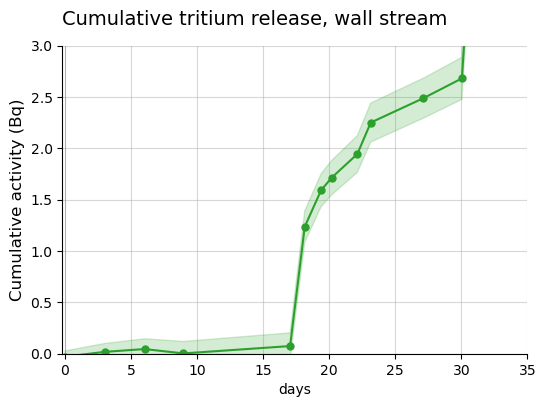

In [8]:
plt.figure(figsize=(6, 4))
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=0.5)
plt.grid(alpha=0.5)
plt.ylim(bottom=0 * ureg.Bq)

# Get cumulative activities and their errors for wall stream
ov_cumulative = OV_stream_with_errors.get_cumulative_activity("total")
ov_errors = OV_stream_with_errors.get_cumulative_activity_errors("total")

# Convert times to numpy arrays for plotting
times_walls = np.array([t.magnitude for t in replacement_times_walls])

# Extract magnitudes for cumulative values (they have units)
ov_cumulative_mag = ov_cumulative.magnitude if hasattr(ov_cumulative, 'magnitude') else ov_cumulative

# Plot line with error band
plt.plot(times_walls, ov_cumulative_mag, color="tab:green", linewidth=1.5, marker='o', markersize=5)
plt.fill_between(
    times_walls,
    ov_cumulative_mag - ov_errors,
    ov_cumulative_mag + ov_errors,
    color="tab:green",
    alpha=0.2
)

plt.title("Cumulative tritium release, wall stream", loc="left", fontsize=14, pad=15)
plt.ylim(top=3)
plt.xlim(right = 35)
plt.xlim(left = -0.2)
plt.xlabel("days")
plt.ylabel("Cumulative activity (Bq)", fontsize=12)

plt.savefig("outputs/cumulative_OV_release.png", bbox_inches="tight")

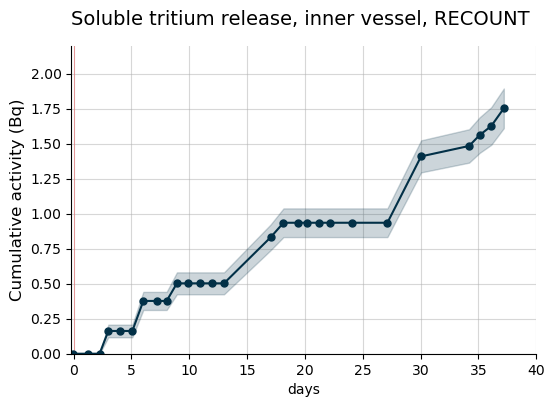

In [9]:
plt.figure(figsize=(6, 4))
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=0.5)
plt.grid(alpha=0.5)
plt.ylim(bottom=0 * ureg.Bq)

# Get cumulative activities and their errors for inner vessel stream - SOLUBLE only
iv_cumulative = IV_stream_with_errors.get_cumulative_activity("soluble")
iv_errors = IV_stream_with_errors.get_cumulative_activity_errors("soluble")

# Convert times to numpy arrays for plotting
times_top = np.array([t.magnitude for t in replacement_times_top])

# Extract magnitudes for cumulative values (they have units)
iv_cumulative_mag = iv_cumulative.magnitude if hasattr(iv_cumulative, 'magnitude') else iv_cumulative

# Plot line with error band
plt.plot(times_top, iv_cumulative_mag, color="#023047", linewidth=1.5, marker='o', markersize=5)
plt.fill_between(
    times_top,
    iv_cumulative_mag - iv_errors,
    iv_cumulative_mag + iv_errors,
    color="#023047",
    alpha=0.2
)

plt.title("Soluble tritium release, inner vessel, RECOUNT", loc="left", fontsize=14, pad=15)
plt.ylim(top=2.2)
plt.xlim(right = 40)
plt.xlim(left = -0.2)
plt.xlabel("days")
plt.ylabel("Cumulative activity (Bq)", fontsize=12)

plt.savefig("outputs/cumulative_IV_release_soluble.png", bbox_inches="tight")

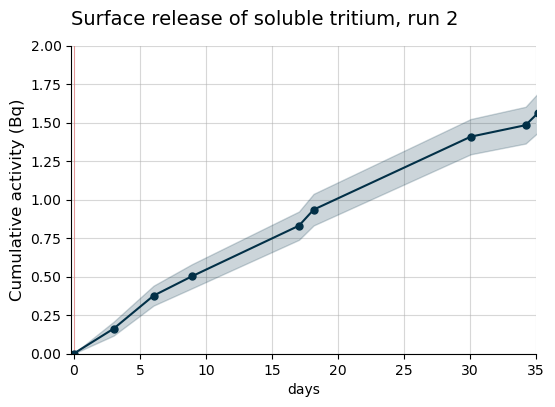

In [10]:
plt.figure(figsize=(6, 4))
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=0.5)
plt.grid(alpha=0.5)
plt.ylim(bottom=0 * ureg.Bq)

# Get cumulative activities and their errors for inner vessel stream - SOLUBLE only
iv_cumulative = IV_stream_with_errors.get_cumulative_activity("soluble")
iv_errors = IV_stream_with_errors.get_cumulative_activity_errors("soluble")

# Convert times to numpy arrays for plotting
times_top = np.array([t.magnitude for t in replacement_times_top])

# Extract magnitudes for cumulative values (they have units)
iv_cumulative_mag = iv_cumulative.magnitude if hasattr(iv_cumulative, 'magnitude') else iv_cumulative

# Keep zeros, keep duplicate-x points, but drop points whose y matches nearest point at lower x
y_values = np.asarray(iv_cumulative_mag)
err_values = np.asarray(iv_errors)
keep_mask = np.ones(len(times_top), dtype=bool)

current_x = times_top[0]
prev_lower_x_y = None

for i in range(1, len(times_top)):
    if times_top[i] > current_x:
        prev_lower_x_y = y_values[i - 1]
        current_x = times_top[i]

    if prev_lower_x_y is not None and np.isclose(y_values[i], prev_lower_x_y):
        keep_mask[i] = False

times_top_filtered = times_top[keep_mask]
iv_cumulative_mag_filtered = y_values[keep_mask]
iv_errors_filtered = err_values[keep_mask]

# Plot line with error band
plt.plot(times_top_filtered, iv_cumulative_mag_filtered, color="#023047", linewidth=1.5, marker='o', markersize=5)
plt.fill_between(
    times_top_filtered,
    iv_cumulative_mag_filtered - iv_errors_filtered,
    iv_cumulative_mag_filtered + iv_errors_filtered,
    color="#023047",
    alpha=0.2
)

plt.title("Surface release of soluble tritium, run 2", loc="left", fontsize=14, pad=15)
plt.ylim(top=2)
plt.xlim(right = 35)
plt.xlim(left = -0.2)
plt.xlabel("days")
plt.ylabel("Cumulative activity (Bq)", fontsize=12)

plt.savefig("outputs/cumulative_IV_release_soluble.png", bbox_inches="tight")

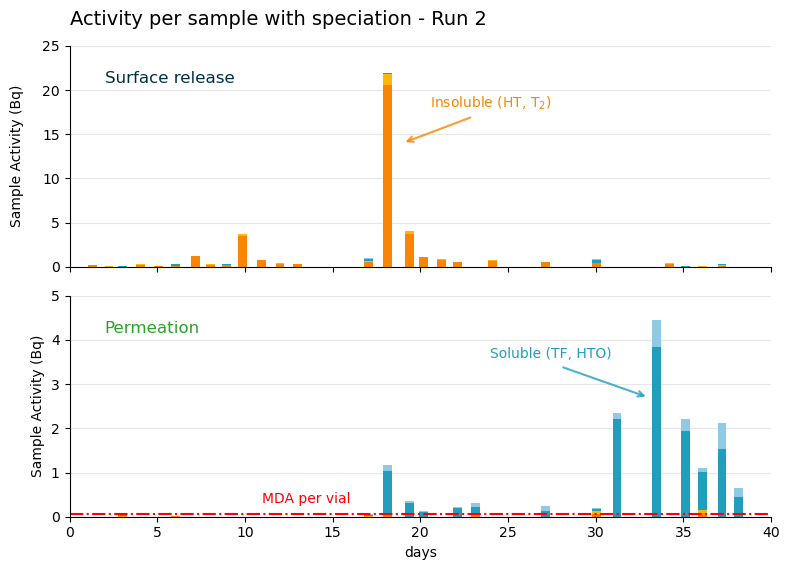

In [11]:
# Create figure with two subplots for bar charts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.8), sharex=True)

# Top plot: Inner vessel
plt.sca(ax1)
plot_bars(IV_stream, index=[time.to(ureg.day) for time in replacement_times_top], bar_width = 0.5)

ax1.grid(True, axis="y", alpha=0.3)
ax1.set_ylim(bottom=0, top=25)
ax1.set_xlim(0, 40)
ax1.set_ylabel("Sample Activity (Bq)", labelpad=13)
ax1.set_title("Activity per sample with speciation - Run 2", loc="left", pad=15, fontsize=14)

# Add text label
ax1.text(2, ax1.get_ylim()[1] * 0.85, 'Surface release', 
         color='#023047', va='center', fontsize=12)

# Add insoluble species label
ax1.text(24, 18, r'Insoluble (HT, T$_2$)', 
         color='#FB8500', ha='center', fontsize=10)

ax1.annotate('', xy=(19, 14), xytext=(23, 17),
             arrowprops=dict(arrowstyle='->', color='#FB8500', alpha=0.8, lw=1.5))

# Bottom plot: Outer vessel
plt.sca(ax2)
plot_bars(OV_stream, index=[time.to(ureg.day) for time in replacement_times_walls], bar_width = 0.5)

ax2.grid(True, axis="y", alpha=0.3)
ax2.set_ylim(bottom=0, top=5)
ax2.set_xlim(0, 40)
ax2.set_ylabel("Sample Activity (Bq)")
ax2.set_xlabel("days")

# Add MDA line
MDA = 0.071  # Calculated by hand for demo, TODO create code to calculate automatically
ax2.axhline(y=MDA, color = "red", linestyle = "-.")
ax2.annotate(
    f"MDA per vial",
    (13.5, 0.25),
    xytext=(0, 0),
    textcoords="offset points",
    ha="center",
    va="bottom",
    color="red",
)

# Add text label
ax2.text(2, ax2.get_ylim()[1] * 0.85, 'Permeation', 
         color='tab:green', va='center', fontsize=12)

# Add soluble species label
ax2.text(24, 3.6, r'Soluble (TF, HTO)', 
         color='#219EBC', fontsize=10)

ax2.annotate('', xy=(33, 2.7), xytext=(28, 3.4),
             arrowprops=dict(arrowstyle='->', color='#219EBC', alpha=0.8, lw=1.5))

plt.tight_layout()
plt.savefig('outputs/per_sample_activity.pdf', bbox_inches='tight')
plt.savefig('outputs/per_sample_activity.svg', bbox_inches='tight')
plt.savefig('outputs/per_sample_activity.png', bbox_inches='tight')
plt.show()
